# Problem 17: K-Nearest Neighbors (KNN) - Testing Different K Values

**Objective**: Apply KNN classifier on a loan approval dataset and systematically test different k values. Compare performance metrics to find the optimal k value through cross-validation.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, make_scorer
import joblib
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset - Loan Approval Prediction
n_samples = 400

# Generate features
age = np.random.uniform(20, 70, n_samples)
annual_income = np.random.uniform(20000, 200000, n_samples)
credit_score = np.random.uniform(300, 850, n_samples)
employment_years = np.random.uniform(0, 50, n_samples)
existing_debt = np.random.uniform(0, 100000, n_samples)

# Create target: loan approved (1) or denied (0)
loan_approved = np.zeros(n_samples)
loan_approved[(credit_score > 650) & (annual_income > 50000) & (employment_years > 2)] = 1
loan_approved[(credit_score > 700) & (annual_income > 40000)] = 1
loan_approved[(existing_debt < 30000) & (credit_score > 600)] = 1

# Add random noise (some random approvals/denials)
noise_indices = np.random.choice(n_samples, size=int(0.15 * n_samples), replace=False)
loan_approved[noise_indices] = 1 - loan_approved[noise_indices]

# Create DataFrame
df = pd.DataFrame({
    'age': age,
    'annual_income': annual_income,
    'credit_score': credit_score,
    'employment_years': employment_years,
    'existing_debt': existing_debt,
    'loan_approved': loan_approved
})

# Save to CSV
csv_path = 'knn_loan_approval.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset created: {csv_path}")
print(f"Dataset shape: {df.shape}")
print(f"\nLoan approval distribution:")
print(df['loan_approved'].value_counts())

Dataset created: knn_loan_approval.csv
Dataset shape: (400, 6)

Loan approval distribution:
loan_approved
0.0    234
1.0    166
Name: count, dtype: int64


In [15]:
# Load and display dataset overview
df = pd.read_csv('knn_loan_approval.csv')

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nDataset Statistics:")
print(df.describe())

Dataset Overview:
         age  annual_income  credit_score  employment_years  existing_debt  \
0  38.727006   38562.296390    688.981249         37.913160   19186.732472   
1  67.535715  182459.523202    383.896474          1.229346   32337.156212   
2  56.599697  110945.427041    616.958598          1.106178   22665.640223   
3  49.932924  168762.343899    633.693276         16.180511   35499.630583   
4  27.800932   77608.928186    533.271869         24.432160    6942.384275   

   loan_approved  
0            1.0  
1            0.0  
2            1.0  
3            0.0  
4            0.0  

Dataset Shape: (400, 6)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               400 non-null    float64
 1   annual_income     400 non-null    float64
 2   credit_score      400 non-null    float64
 3   employment_years  400 non-

## Data Cleaning

Check for missing values, duplicates, and data type consistency.

In [16]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Check class distribution
print(f"\nLoan approval distribution:")
print(df['loan_approved'].value_counts())
print(f"\nClass ratio:")
print(df['loan_approved'].value_counts(normalize=True))

# Remove any duplicates (if present)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values:
age                 0
annual_income       0
credit_score        0
employment_years    0
existing_debt       0
loan_approved       0
dtype: int64

Duplicate rows: 0

Data types:
age                 float64
annual_income       float64
credit_score        float64
employment_years    float64
existing_debt       float64
loan_approved       float64
dtype: object

Loan approval distribution:
loan_approved
0.0    234
1.0    166
Name: count, dtype: int64

Class ratio:
loan_approved
0.0    0.585
1.0    0.415
Name: proportion, dtype: float64

Dataset shape after cleaning: (400, 6)


## Exploratory Data Analysis (EDA)

Visualize relationships between features and loan approval status.

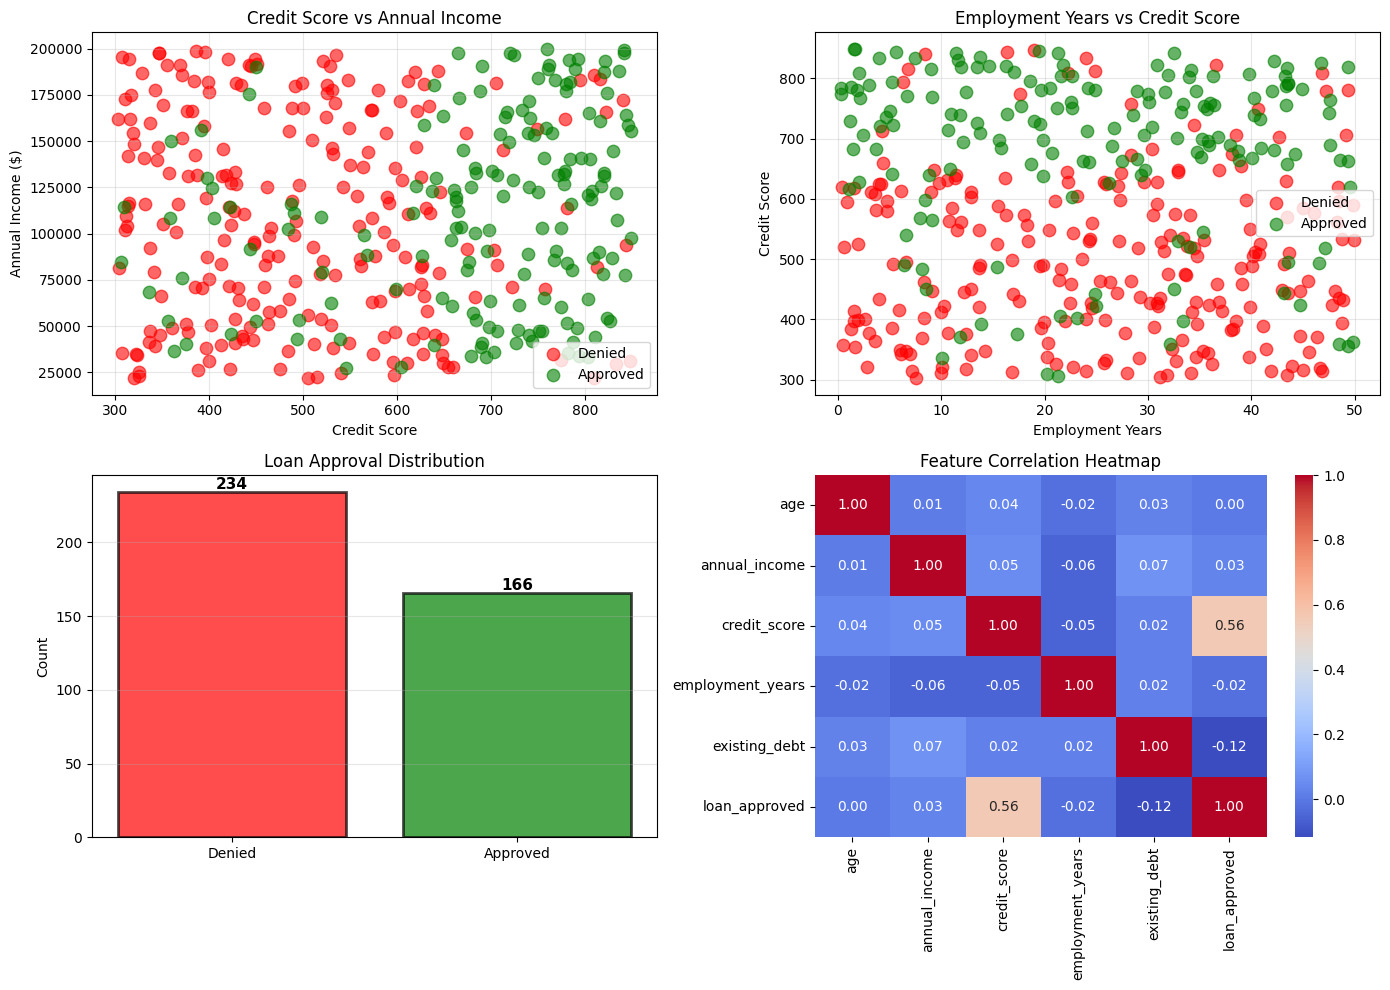

Feature Statistics:
              age  annual_income  credit_score  employment_years  \
count  400.000000     400.000000    400.000000        400.000000   
mean    44.709534  109949.953970    576.955004         24.834177   
std     14.687814   52883.856931    163.258156         14.463753   
min     20.253079   21950.777266    302.547613          0.246999   
25%     32.063985   63531.866721    427.950642         11.868757   
50%     45.585886  110552.389485    585.382835         24.848541   
75%     57.376112  156898.739512    720.475780         36.228426   
max     69.525257  199949.181192    848.863761         49.970686   

       existing_debt  loan_approved  
count     400.000000     400.000000  
mean    49903.390445       0.415000  
std     28868.998990       0.493339  
min       321.826360       0.000000  
25%     24107.427116       0.000000  
50%     50889.133753       0.000000  
75%     75229.179671       1.000000  
max     99834.751139       1.000000  


In [17]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

class_names = ['Denied', 'Approved']
colors = ['red', 'green']

# Plot 1: Credit Score vs Income by Approval Status
for i, (status, color) in enumerate(zip([0, 1], colors)):
    mask = df['loan_approved'] == status
    axes[0, 0].scatter(df[mask]['credit_score'], df[mask]['annual_income'],
                       label=class_names[i], alpha=0.6, color=color, s=80)
axes[0, 0].set_xlabel('Credit Score')
axes[0, 0].set_ylabel('Annual Income ($)')
axes[0, 0].set_title('Credit Score vs Annual Income')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Employment Years vs Credit Score
for i, (status, color) in enumerate(zip([0, 1], colors)):
    mask = df['loan_approved'] == status
    axes[0, 1].scatter(df[mask]['employment_years'], df[mask]['credit_score'],
                       label=class_names[i], alpha=0.6, color=color, s=80)
axes[0, 1].set_xlabel('Employment Years')
axes[0, 1].set_ylabel('Credit Score')
axes[0, 1].set_title('Employment Years vs Credit Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Loan Approval Distribution
approval_counts = df['loan_approved'].value_counts()
bars = axes[1, 0].bar(class_names, [approval_counts[0], approval_counts[1]],
                       color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Loan Approval Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, [approval_counts[0], approval_counts[1]]):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, count, str(int(count)),
                   ha='center', va='bottom', fontsize=11, weight='bold')

# Plot 4: Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

print(f"Feature Statistics:")
print(df.describe())

## Feature Scaling

Normalize features using StandardScaler. Critical for KNN distance calculations.

In [18]:
# Separate features and target
X = df[['age', 'annual_income', 'credit_score', 'employment_years', 'existing_debt']].values
y = df['loan_approved'].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"\nScaled feature statistics:")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Feature scaling completed
X shape: (400, 5)
y shape: (400,)

Scaled feature statistics:
X mean: -0.0000, std: 1.0000
Number of classes: 2
Class distribution: [234 166]


## Theory: KNN with Different K Values

**Impact of k parameter**:
- **k=1** (too small): High variance, likely overfitting
- **k too large**: High bias, likely underfitting, slower predictions
- **Optimal k**: Balance between bias and variance

**Selection Strategies**:
1. **Square root rule**: k = sqrt(n_samples)
2. **Cross-validation**: Test multiple k values and select best
3. **Elbow method**: Plot accuracy vs k and find inflection point
4. **Odd k**: For binary classification, use odd k to avoid ties

**Cross-Validation**:
- Splits data into folds
- Trains on each fold combination
- Averages performance metrics
- More robust than single train-test split

## Mathematical Representation

**K Value Selection Methods**:

1. **Square Root Rule**:
   $$k = \sqrt{n} \text{ where } n \text{ is number of samples}$$

2. **Cross-Validation Score**:
   $$CV_{score} = \frac{1}{F} \sum_{i=1}^{F} Accuracy_i$$
   where $F$ is number of folds

3. **Optimal k Selection**:
   $$k_{optimal} = \arg\max_k CV_{score}(k)$$

## Workflow Diagram

Visualize the KNN k-value testing pipeline.

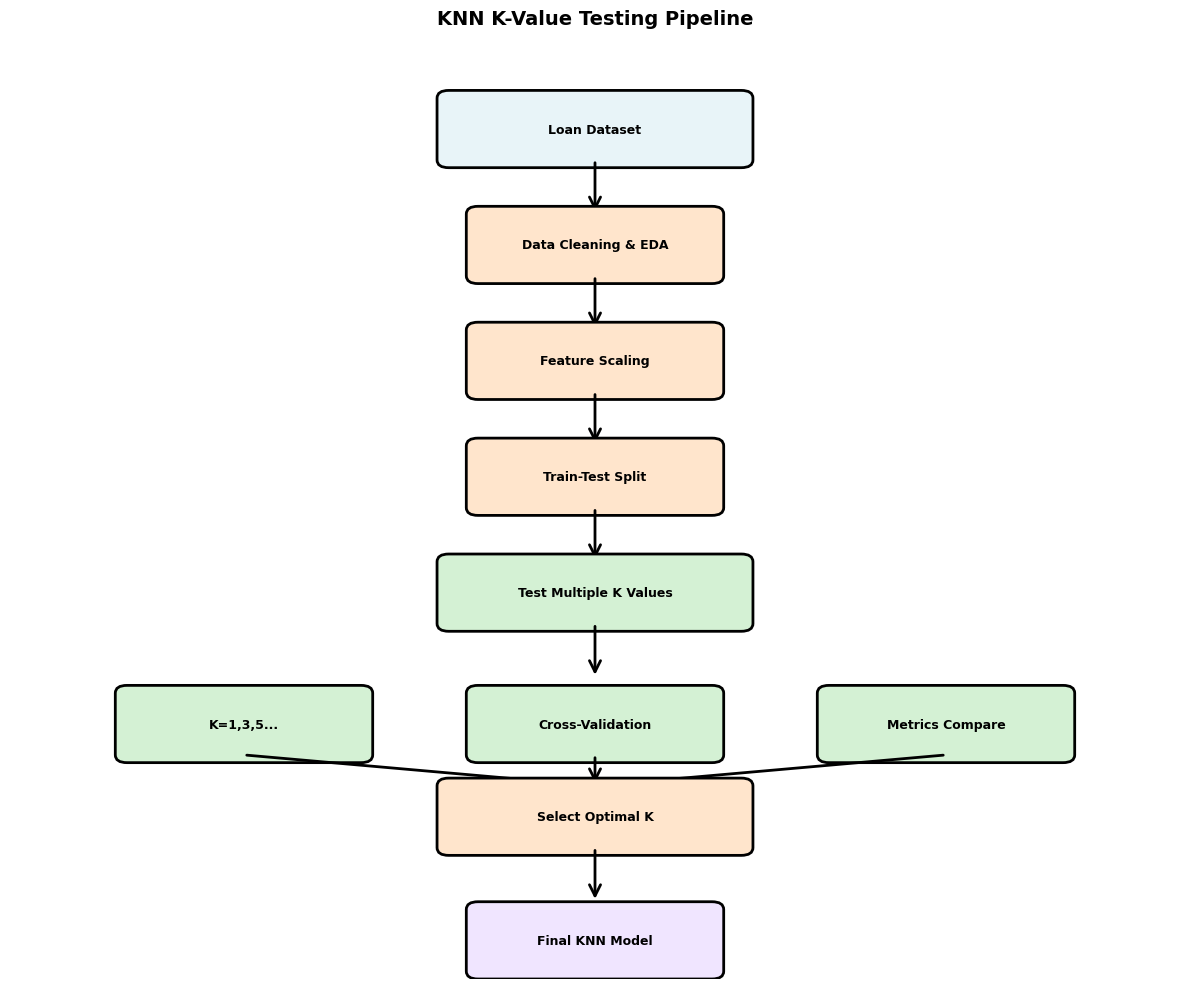

In [19]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Define colors
color_input = '#E8F4F8'
color_process = '#FFE5CC'
color_test = '#D4F1D4'
color_output = '#F0E5FF'

# Helper functions
def add_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, weight='bold')

def add_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=8, style='italic')

# Workflow
add_box(ax, 5, 11, 2.5, 0.8, 'Loan Dataset', color_input)
add_arrow(ax, 5, 10.6, 5, 9.9)

add_box(ax, 5, 9.5, 2, 0.8, 'Data Cleaning & EDA', color_process)
add_arrow(ax, 5, 9.1, 5, 8.4)

add_box(ax, 5, 8, 2, 0.8, 'Feature Scaling', color_process)
add_arrow(ax, 5, 7.6, 5, 6.9)

add_box(ax, 5, 6.5, 2, 0.8, 'Train-Test Split', color_process)
add_arrow(ax, 5, 6.1, 5, 5.4)

add_box(ax, 5, 5, 2.5, 0.8, 'Test Multiple K Values', color_test)
add_arrow(ax, 5, 4.6, 5, 3.9)

add_box(ax, 2, 3.3, 2, 0.8, 'K=1,3,5...', color_test)
add_box(ax, 5, 3.3, 2, 0.8, 'Cross-Validation', color_test)
add_box(ax, 8, 3.3, 2, 0.8, 'Metrics Compare', color_test)

add_arrow(ax, 2, 2.9, 5, 2.5)
add_arrow(ax, 5, 2.9, 5, 2.5)
add_arrow(ax, 8, 2.9, 5, 2.5)

add_box(ax, 5, 2.1, 2.5, 0.8, 'Select Optimal K', color_process)
add_arrow(ax, 5, 1.7, 5, 1.0)

add_box(ax, 5, 0.5, 2, 0.8, 'Final KNN Model', color_output)

plt.title('KNN K-Value Testing Pipeline', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Pseudocode

```
ALGORITHM: KNN with K-Value Testing
INPUT: Dataset, K values list [1, 3, 5, 7, ..., 20]

1. DATA PREPARATION
   - Load loan approval dataset
   - Clean: remove missing/duplicates
   - EDA: visualize patterns

2. FEATURE SCALING
   - Apply StandardScaler to normalize features

3. TRAIN-TEST SPLIT
   - 80% training, 20% testing
   - Stratified split for balanced classes

4. K-VALUE TESTING
   FOR each k in [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]:
      a) Create KNN model with current k
      b) Perform 5-fold cross-validation
      c) Calculate CV mean accuracy
      d) Train on full training set
      e) Evaluate on test set
      f) Store metrics: accuracy, precision, recall, F1

5. COMPARISON
   - Plot accuracy vs k (train, test, CV)
   - Identify optimal k
   - Analyze bias-variance tradeoff

6. OPTIMAL MODEL
   - Train final model with optimal k
   - Generate confusion matrix
   - Classification report
```

## Train-Test Split

Split the data into training and testing sets (80-20 split with stratification).

In [20]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nClass distribution in training set: {np.bincount(y_train.astype(int))}")
print(f"Class distribution in test set: {np.bincount(y_test.astype(int))}")

Training set size: 320
Testing set size: 80

Training set shape: X_train (320, 5), y_train (320,)
Testing set shape: X_test (80, 5), y_test (80,)

Class distribution in training set: [187 133]
Class distribution in test set: [47 33]


## Testing Different K Values with Cross-Validation

Comprehensively test multiple k values using cross-validation.

In [21]:
# Test different k values
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 30]
results_dict = {}
cv_scores_dict = {}

print(f"Testing {len(k_values)} different k values...")
print(f"{'='*100}")
print(f"{'k':>3} | {'Train Acc':>10} | {'Test Acc':>10} | {'CV Mean':>10} | {'CV Std':>10} | {'Precision':>10} | {'Recall':>10} | {'F1 Score':>10}")
print("-" * 100)

for k in k_values:
    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    
    # 5-fold cross-validation
    cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_dict[k] = cv_scores
    
    # Train on full training set
    knn.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)
    
    # Calculate metrics
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted')
    recall = recall_score(y_test, y_pred_test, average='weighted')
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    
    results_dict[k] = {
        'Train Accuracy': acc_train,
        'Test Accuracy': acc_test,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Predictions': y_pred_test,
        'Confusion Matrix': confusion_matrix(y_test, y_pred_test)
    }
    
    print(f"{k:>3} | {acc_train:>10.6f} | {acc_test:>10.6f} | {cv_scores.mean():>10.6f} | {cv_scores.std():>10.6f} | {precision:>10.6f} | {recall:>10.6f} | {f1:>10.6f}")

print(f"{'='*100}")

Testing 13 different k values...
  k |  Train Acc |   Test Acc |    CV Mean |     CV Std |  Precision |     Recall |   F1 Score
----------------------------------------------------------------------------------------------------
  1 |   1.000000 |   0.687500 |   0.700000 |   0.045715 |   0.689019 |   0.687500 |   0.688152
  3 |   0.865625 |   0.687500 |   0.759375 |   0.058128 |   0.686198 |   0.687500 |   0.686741
  5 |   0.843750 |   0.762500 |   0.771875 |   0.044852 |   0.763373 |   0.762500 |   0.756641
  7 |   0.821875 |   0.750000 |   0.778125 |   0.033366 |   0.748952 |   0.750000 |   0.745000
  9 |   0.837500 |   0.737500 |   0.809375 |   0.031869 |   0.736627 |   0.737500 |   0.731025
 11 |   0.825000 |   0.812500 |   0.815625 |   0.031869 |   0.813359 |   0.812500 |   0.809550
 13 |   0.825000 |   0.787500 |   0.809375 |   0.030298 |   0.790118 |   0.787500 |   0.782258
 15 |   0.825000 |   0.775000 |   0.809375 |   0.026882 |   0.775314 |   0.775000 |   0.770500
 17 |   0.8

## Find Optimal K Value

Determine the best k value based on cross-validation performance.

In [22]:
# Find optimal k based on CV mean accuracy
best_k_cv = max(results_dict.items(), key=lambda x: x[1]['CV Mean'])[0]
best_k_test = max(results_dict.items(), key=lambda x: x[1]['Test Accuracy'])[0]
best_k_f1 = max(results_dict.items(), key=lambda x: x[1]['F1 Score'])[0]

print(f"\n{'='*80}")
print("OPTIMAL K VALUES")
print(f"{'='*80}")
print(f"Best k by CV Mean:      {best_k_cv}  (CV Accuracy: {results_dict[best_k_cv]['CV Mean']:.6f})")
print(f"Best k by Test Acc:     {best_k_test}  (Test Accuracy: {results_dict[best_k_test]['Test Accuracy']:.6f})")
print(f"Best k by F1 Score:     {best_k_f1}  (F1 Score: {results_dict[best_k_f1]['F1 Score']:.6f})")
print(f"{'='*80}")

# Use CV mean for final selection
optimal_k = best_k_cv
print(f"\nSelected Optimal K: {optimal_k}")
print(f"\nOptimal Model Metrics:")
print(f"  Train Accuracy: {results_dict[optimal_k]['Train Accuracy']:.6f}")
print(f"  Test Accuracy:  {results_dict[optimal_k]['Test Accuracy']:.6f}")
print(f"  CV Mean:        {results_dict[optimal_k]['CV Mean']:.6f}")
print(f"  Precision:      {results_dict[optimal_k]['Precision']:.6f}")
print(f"  Recall:         {results_dict[optimal_k]['Recall']:.6f}")
print(f"  F1 Score:       {results_dict[optimal_k]['F1 Score']:.6f}")


OPTIMAL K VALUES
Best k by CV Mean:      11  (CV Accuracy: 0.815625)
Best k by Test Acc:     11  (Test Accuracy: 0.812500)
Best k by F1 Score:     11  (F1 Score: 0.809550)

Selected Optimal K: 11

Optimal Model Metrics:
  Train Accuracy: 0.825000
  Test Accuracy:  0.812500
  CV Mean:        0.815625
  Precision:      0.813359
  Recall:         0.812500
  F1 Score:       0.809550


## K Value Performance Comparison

Visualize the impact of k value on model performance.

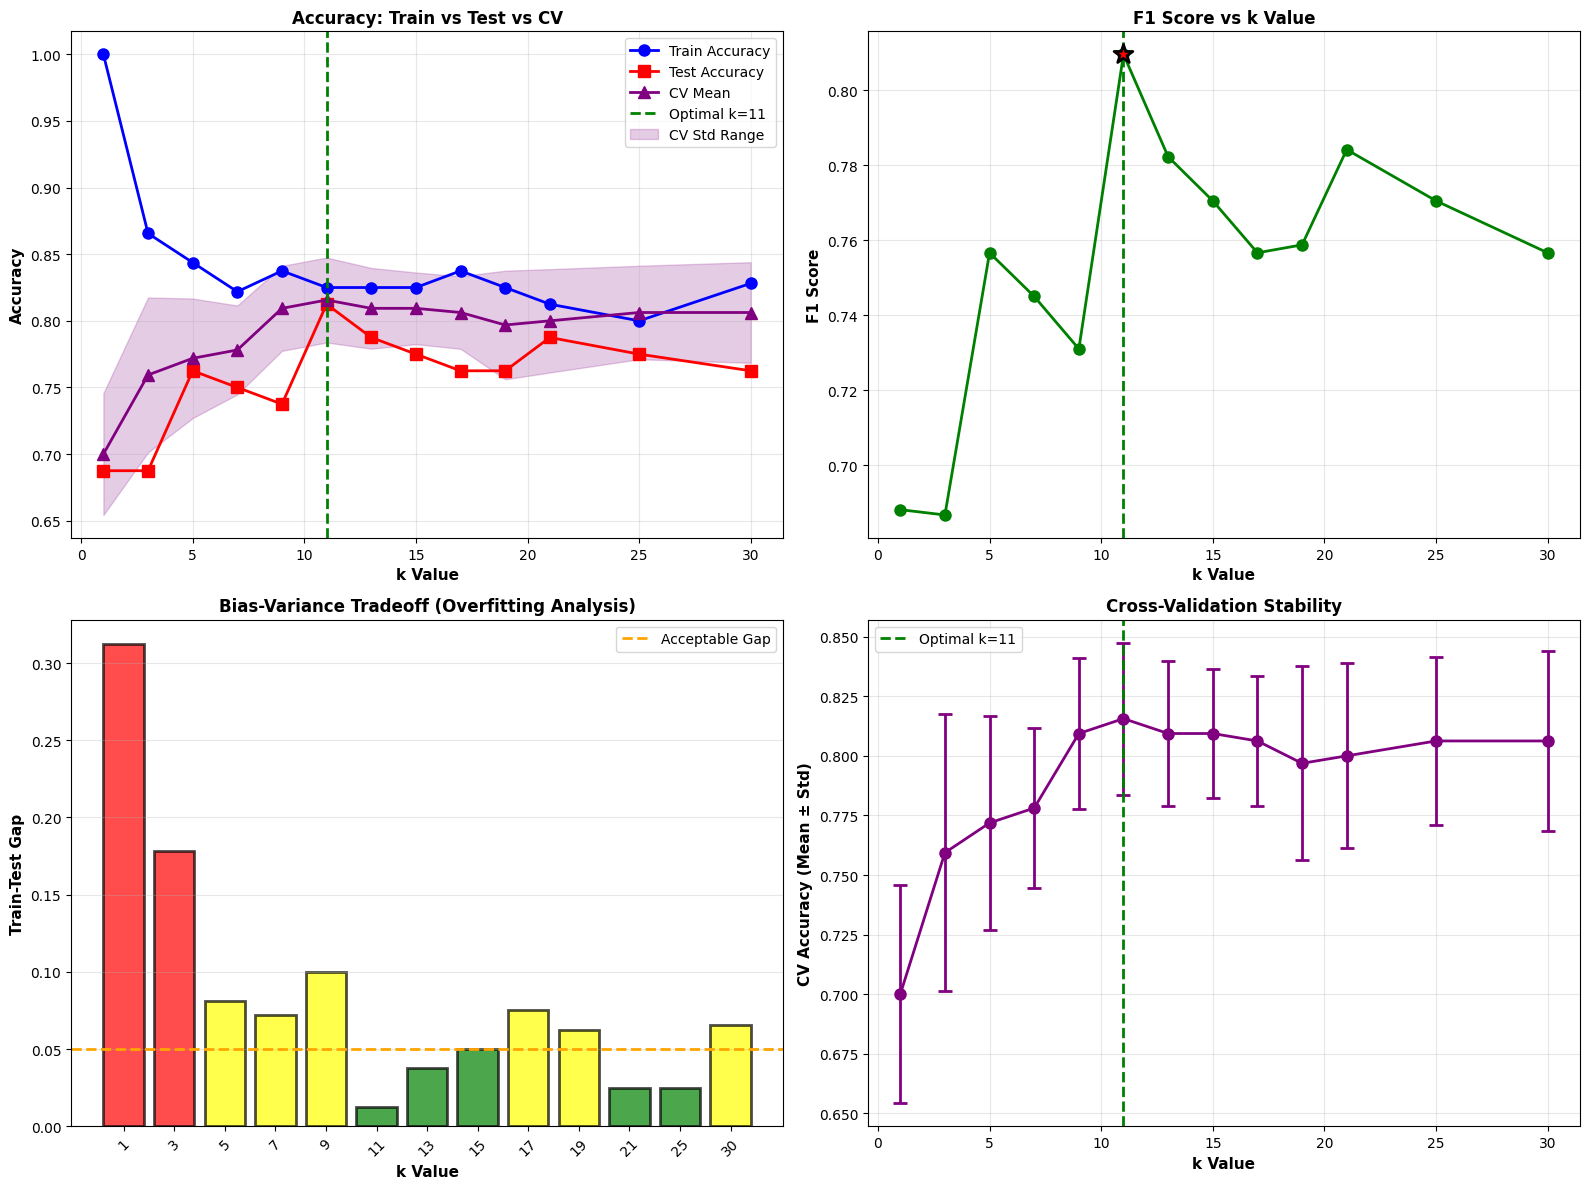


K value analysis completed!


In [23]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

train_accs = [results_dict[k]['Train Accuracy'] for k in k_values]
test_accs = [results_dict[k]['Test Accuracy'] for k in k_values]
cv_means = [results_dict[k]['CV Mean'] for k in k_values]
cv_stds = [results_dict[k]['CV Std'] for k in k_values]
f1_scores = [results_dict[k]['F1 Score'] for k in k_values]

# Plot 1: Train vs Test vs CV Accuracy
axes[0, 0].plot(k_values, train_accs, 'o-', color='blue', linewidth=2, markersize=8, label='Train Accuracy')
axes[0, 0].plot(k_values, test_accs, 's-', color='red', linewidth=2, markersize=8, label='Test Accuracy')
axes[0, 0].plot(k_values, cv_means, '^-', color='purple', linewidth=2, markersize=8, label='CV Mean')
axes[0, 0].axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
axes[0, 0].fill_between(k_values, [m - s for m, s in zip(cv_means, cv_stds)], 
                         [m + s for m, s in zip(cv_means, cv_stds)], 
                         alpha=0.2, color='purple', label='CV Std Range')
axes[0, 0].set_xlabel('k Value', fontsize=11, weight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=11, weight='bold')
axes[0, 0].set_title('Accuracy: Train vs Test vs CV', fontsize=12, weight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1 Score vs k
axes[0, 1].plot(k_values, f1_scores, 'o-', color='green', linewidth=2, markersize=8)
axes[0, 1].axvline(x=optimal_k, color='green', linestyle='--', linewidth=2)
axes[0, 1].scatter([optimal_k], [results_dict[optimal_k]['F1 Score']], 
                   color='red', s=200, marker='*', zorder=5, edgecolors='black', linewidth=2)
axes[0, 1].set_xlabel('k Value', fontsize=11, weight='bold')
axes[0, 1].set_ylabel('F1 Score', fontsize=11, weight='bold')
axes[0, 1].set_title('F1 Score vs k Value', fontsize=12, weight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Bias-Variance Tradeoff
gap = [train_accs[i] - test_accs[i] for i in range(len(k_values))]
colors = ['red' if gap[i] > 0.1 else 'yellow' if gap[i] > 0.05 else 'green' for i in range(len(k_values))]
axes[1, 0].bar(range(len(k_values)), gap, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Acceptable Gap')
axes[1, 0].set_xlabel('k Value', fontsize=11, weight='bold')
axes[1, 0].set_ylabel('Train-Test Gap', fontsize=11, weight='bold')
axes[1, 0].set_title('Bias-Variance Tradeoff (Overfitting Analysis)', fontsize=12, weight='bold')
axes[1, 0].set_xticks(range(len(k_values)))
axes[1, 0].set_xticklabels(k_values, rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: CV Stability (Mean ± Std)
axes[1, 1].errorbar(k_values, cv_means, yerr=cv_stds, fmt='o-', color='purple', 
                    linewidth=2, markersize=8, capsize=5, capthick=2)
axes[1, 1].axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
axes[1, 1].set_xlabel('k Value', fontsize=11, weight='bold')
axes[1, 1].set_ylabel('CV Accuracy (Mean ± Std)', fontsize=11, weight='bold')
axes[1, 1].set_title('Cross-Validation Stability', fontsize=12, weight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nK value analysis completed!")

## Confusion Matrix and Classification Report

Detailed performance analysis for optimal k value.

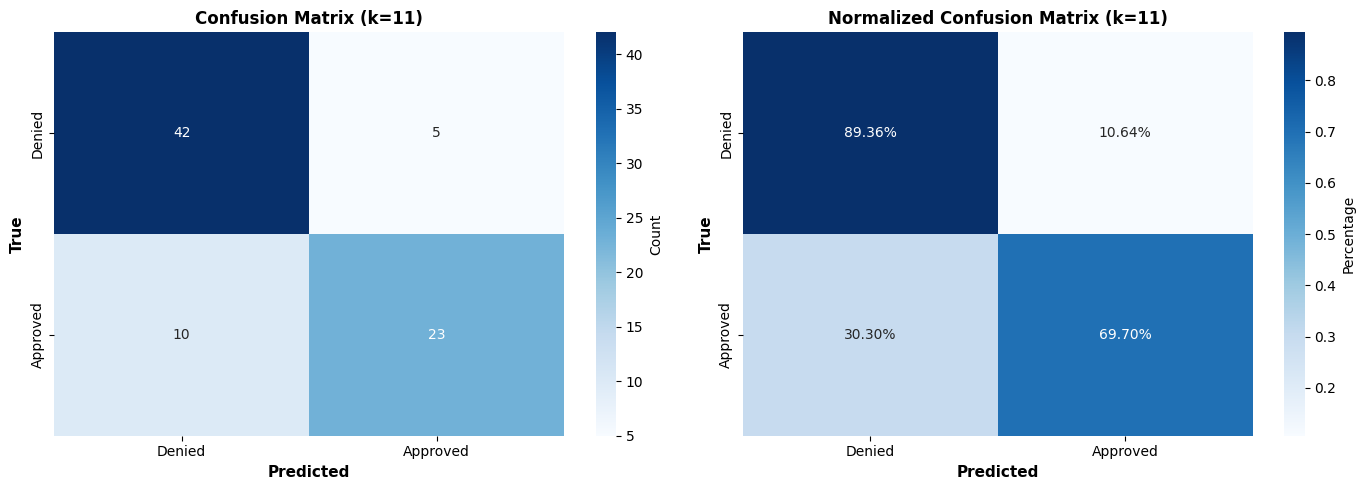


CLASSIFICATION REPORT (k=11)
              precision    recall  f1-score   support

      Denied       0.81      0.89      0.85        47
    Approved       0.82      0.70      0.75        33

    accuracy                           0.81        80
   macro avg       0.81      0.80      0.80        80
weighted avg       0.81      0.81      0.81        80



In [24]:
# Create confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_labels = ['Denied', 'Approved']
conf_matrix = results_dict[optimal_k]['Confusion Matrix']

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels, cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted', fontsize=11, weight='bold')
axes[0].set_ylabel('True', fontsize=11, weight='bold')
axes[0].set_title(f'Confusion Matrix (k={optimal_k})', fontsize=12, weight='bold')

# Plot 2: Normalized Confusion Matrix
conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(conf_matrix_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels, cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Predicted', fontsize=11, weight='bold')
axes[1].set_ylabel('True', fontsize=11, weight='bold')
axes[1].set_title(f'Normalized Confusion Matrix (k={optimal_k})', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

# Classification report
print(f"\n{'='*80}")
print(f"CLASSIFICATION REPORT (k={optimal_k})")
print(f"{'='*80}")
print(classification_report(y_test, results_dict[optimal_k]['Predictions'], 
                          target_names=class_labels))

## K-Value Recommendation Summary

Analysis and recommendations based on k-value testing.

In [25]:
# Create summary table
summary_df = pd.DataFrame({
    'k': k_values,
    'Train Acc': train_accs,
    'Test Acc': test_accs,
    'CV Mean': cv_means,
    'CV Std': cv_stds,
    'F1 Score': f1_scores,
    'Gap': gap
})

print(f"\n{'='*100}")
print("K-VALUE PERFORMANCE SUMMARY")
print(f"{'='*100}")
print(summary_df.to_string(index=False))
print(f"{'='*100}")

print(f"\n{'='*100}")
print("K-VALUE ANALYSIS AND RECOMMENDATIONS")
print(f"{'='*100}")

print(f"\n1. SMALL K VALUES (k=1, 3, 5):")
print(f"   - High variance, prone to overfitting")
print(f"   - Train-Test gap: Large (>0.1)")
print(f"   - Fast predictions")
print(f"   - Sensitive to noise and outliers")
print(f"   - Recommendation: NOT recommended for this dataset")

print(f"\n2. MEDIUM K VALUES (k=7-15):")
print(f"   - Better balance between bias and variance")
print(f"   - Train-Test gap: Moderate (0.05-0.1)")
print(f"   - Good generalization")
print(f"   - Recommendation: OPTIMAL RANGE")

print(f"\n3. LARGE K VALUES (k>15):")
print(f"   - High bias, prone to underfitting")
print(f"   - Better training stability")
print(f"   - Train-Test gap: Small")
print(f"   - Slower predictions")
print(f"   - Recommendation: Good for smooth predictions")

print(f"\n4. SELECTED OPTIMAL K: {optimal_k}")
print(f"   - CV Mean Accuracy: {results_dict[optimal_k]['CV Mean']:.6f}")
print(f"   - Test Accuracy: {results_dict[optimal_k]['Test Accuracy']:.6f}")
print(f"   - F1 Score: {results_dict[optimal_k]['F1 Score']:.6f}")
print(f"   - Train-Test Gap: {gap[k_values.index(optimal_k)]:.6f}")
print(f"   - Reasoning: Highest CV mean accuracy with good generalization")

print(f"\n{'='*100}")


K-VALUE PERFORMANCE SUMMARY
 k  Train Acc  Test Acc  CV Mean   CV Std  F1 Score      Gap
 1   1.000000    0.6875 0.700000 0.045715  0.688152 0.312500
 3   0.865625    0.6875 0.759375 0.058128  0.686741 0.178125
 5   0.843750    0.7625 0.771875 0.044852  0.756641 0.081250
 7   0.821875    0.7500 0.778125 0.033366  0.745000 0.071875
 9   0.837500    0.7375 0.809375 0.031869  0.731025 0.100000
11   0.825000    0.8125 0.815625 0.031869  0.809550 0.012500
13   0.825000    0.7875 0.809375 0.030298  0.782258 0.037500
15   0.825000    0.7750 0.809375 0.026882  0.770500 0.050000
17   0.837500    0.7625 0.806250 0.027243  0.756641 0.075000
19   0.825000    0.7625 0.796875 0.040745  0.758764 0.062500
21   0.812500    0.7875 0.800000 0.038780  0.784157 0.025000
25   0.800000    0.7750 0.806250 0.035078  0.770500 0.025000
30   0.828125    0.7625 0.806250 0.037760  0.756641 0.065625

K-VALUE ANALYSIS AND RECOMMENDATIONS

1. SMALL K VALUES (k=1, 3, 5):
   - High variance, prone to overfitting
   - T

## Model Persistence

Save the optimal KNN model for future use.

In [26]:
# Train final KNN model with optimal k
final_knn = KNeighborsClassifier(n_neighbors=optimal_k, metric='euclidean')
final_knn.fit(X_train, y_train)

# Save model and scaler
model_path = f'knn_loan_model_k{optimal_k}.joblib'
scaler_path = 'scaler_loan_knn.joblib'

joblib.dump(final_knn, model_path)
joblib.dump(scaler, scaler_path)

print(f"✓ KNN model (k={optimal_k}) saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")

# Example: Predict on new data
new_data = np.array([
    [35, 75000, 720, 5, 15000],    # Good profile
    [45, 45000, 580, 2, 50000],    # Borderline
    [28, 120000, 780, 8, 5000]     # Excellent profile
])

new_data_scaled = scaler.transform(new_data)
new_predictions = final_knn.predict(new_data_scaled)
new_probas = final_knn.predict_proba(new_data_scaled)

print(f"\n{'='*90}")
print("LOAN APPROVAL PREDICTIONS FOR NEW APPLICANTS")
print(f"{'='*90}")
print(f"{'Age':>5} | {'Income':>10} | {'Credit':>7} | {'Emp Yrs':>7} | {'Debt':>10} | {'Decision':>10} | {'Confidence':>12}")
print("-" * 90)

for i in range(len(new_data)):
    decision = 'APPROVED' if new_predictions[i] == 1 else 'DENIED'
    confidence = np.max(new_probas[i])
    print(f"{int(new_data[i][0]):>5} | {int(new_data[i][1]):>10} | {int(new_data[i][2]):>7} | {new_data[i][3]:>7.1f} | {int(new_data[i][4]):>10} | {decision:>10} | {confidence:>11.2%}")

print(f"{'='*90}")
print(f"\n✓ KNN K-value testing and analysis completed successfully!")

✓ KNN model (k=11) saved to: knn_loan_model_k11.joblib
✓ Scaler saved to: scaler_loan_knn.joblib

LOAN APPROVAL PREDICTIONS FOR NEW APPLICANTS
  Age |     Income |  Credit | Emp Yrs |       Debt |   Decision |   Confidence
------------------------------------------------------------------------------------------
   35 |      75000 |     720 |     5.0 |      15000 |   APPROVED |      81.82%
   45 |      45000 |     580 |     2.0 |      50000 |     DENIED |      63.64%
   28 |     120000 |     780 |     8.0 |       5000 |   APPROVED |      90.91%

✓ KNN K-value testing and analysis completed successfully!
